# Mental Health Status Detection from Sentiment Analysis
## Preprocessing & Data Exploration

This notebook implements a comprehensive preprocessing pipeline for multi-class mental health status detection (7 categories) using sentiment analysis and classical machine learning techniques.

## Dataset Description

**Source**: Multiple Kaggle datasets combined  
**Total Columns**: 3  
- **ID**: Unique identifier for each entry
- **Statement**: The textual data or post (text to analyze)
- **Status**: The labeled mental health status

**Mental Health Categories (7 classes)**:
1. Normal
2. Depression
3. Suicidal
4. Anxiety
5. Stress
6. Bipolar
7. Personality Disorder

**Data Sources**: Social media platforms including Reddit, Twitter, surveys, and chatbot conversations

**Purpose**: Multi-class classification for mental health status detection using sentiment analysis and classical ML

## 1. Data Exploration & Understanding

### 1.1 Dataset Overview
First, let's examine the structure, shape, and basic statistics of our dataset.

In [91]:
# Display dataset shape
import pandas as pd
df = pd.read_csv("Combined Data.csv")
print(f"Dataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (53043, 3)
Number of samples: 53043

Column Names:
['id', 'statement', 'status']


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         53043 non-null  int64
 1   statement  52681 non-null  str  
 2   status     53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.2 MB


### 1.2 Missing Values Analysis

In [93]:
# Check for missing values
import numpy as np

print("Missing Values Summary:")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage(%)': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:
           Missing Count  Percentage(%)
statement            362       0.682465


In [94]:
df.drop(labels=['id'], axis=1, inplace=True)

In [95]:
df.info()
df.to_csv("mental_health_dataset_updated.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


### 1.3 Duplicate Records

In [96]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")
    # Remove duplicates
    df = df.drop_duplicates()
    print(f"\n✓ Duplicates removed. New shape: {df.shape}")
else:
    print("\n✓ No duplicates found!")

Number of duplicate rows: 1944
Percentage of duplicates: 3.66%

✓ Duplicates removed. New shape: (51099, 2)


### 1.4 Class Distribution Analysis
Analyze the distribution across 7 mental health categories: Normal, Depression, Suicidal, Anxiety, Stress, Bipolar, and Personality Disorder.

In [97]:
# Dataset has 'Status' column with 7 mental health categories:
# Normal, Depression, Suicidal, Anxiety, Stress, Bipolar, Personality Disorder
label_column = [col for col in df.columns if 'status' in col.lower() or 'label' in col.lower() or 'class' in col.lower() or 'target' in col.lower()]

if label_column:
    label_col = label_column[0]
    print(f"Label Column: '{label_col}'")
    print(f"Number of classes: {df[label_col].nunique()}")
    print("\nClass Distribution:")
    print("=" * 50)
    class_dist = df[label_col].value_counts().sort_values(ascending=False)
    print(class_dist)
    print("\nClass Distribution (%):\n")
    print(df[label_col].value_counts(normalize=True).sort_values(ascending=False) * 100)
    
    # Calculate imbalance ratio for multi-class
    imbalance_ratio = class_dist.max() / class_dist.min()
    print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 2.0:
        print("Dataset is imbalanced - consider using class weights or sampling techniques")
    else:
        print("✓ Dataset is relatively balanced")

else:    print("Label column not found automatically. Please specify manually.")

Label Column: 'status'
Number of classes: 7

Class Distribution:
status
Normal                  16041
Depression              15094
Suicidal                10645
Anxiety                  3624
Bipolar                  2502
Stress                   2297
Personality disorder      896
Name: count, dtype: int64

Class Distribution (%):

status
Normal                  31.392004
Depression              29.538739
Suicidal                20.832110
Anxiety                  7.092115
Bipolar                  4.896378
Stress                   4.495196
Personality disorder     1.753459
Name: proportion, dtype: float64

Imbalance Ratio (max/min): 17.90:1
Dataset is imbalanced - consider using class weights or sampling techniques


### 1.5 Visualize Class Distribution

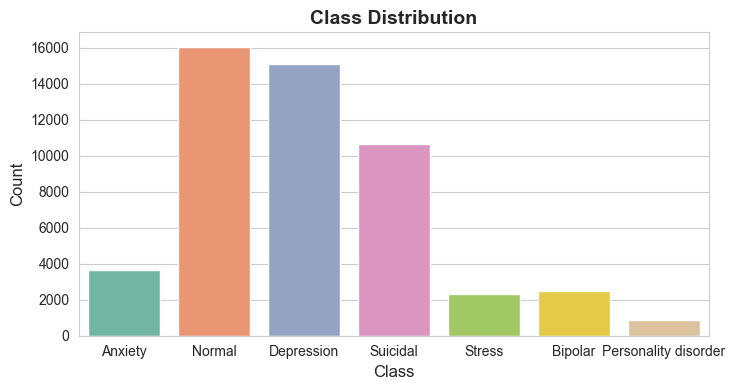

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(14, 4))

if label_column:
    # Count plot
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=label_column[0], palette='Set2')
    plt.title('Class Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)

    
    plt.tight_layout()
    plt.show()

### 1.6 Text Length Distribution
Analyze the length of text samples to understand the data better.

In [99]:
# Identify text column - dataset has 'Statement' column containing text data
text_column = [col for col in df.columns if 'statement' in col.lower() or 'text' in col.lower() or 'comment' in col.lower() or 'post' in col.lower() or 'message' in col.lower()]

if text_column:
    text_col = text_column[0]
    print(f"Text Column: '{text_col}'")
    
    df[text_col] = df[text_col].fillna('')
    
    # Calculate text statistics (now safe because NaN values are handled)
    df['text_length'] = df[text_col].astype(str).apply(len)
    df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
    print(df.head())

else:
    print("Text column not found automatically. Please specify manually.")

Text Column: 'statement'
                                           statement   status  text_length  \
0                                         oh my gosh  Anxiety           10   
1  trouble sleeping, confused mind, restless hear...  Anxiety           64   
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety           78   
3  I've shifted my focus to something else but I'...  Anxiety           61   
4  I'm restless and restless, it's been a month n...  Anxiety           72   

   word_count  
0           3  
1          10  
2          14  
3          11  
4          14  


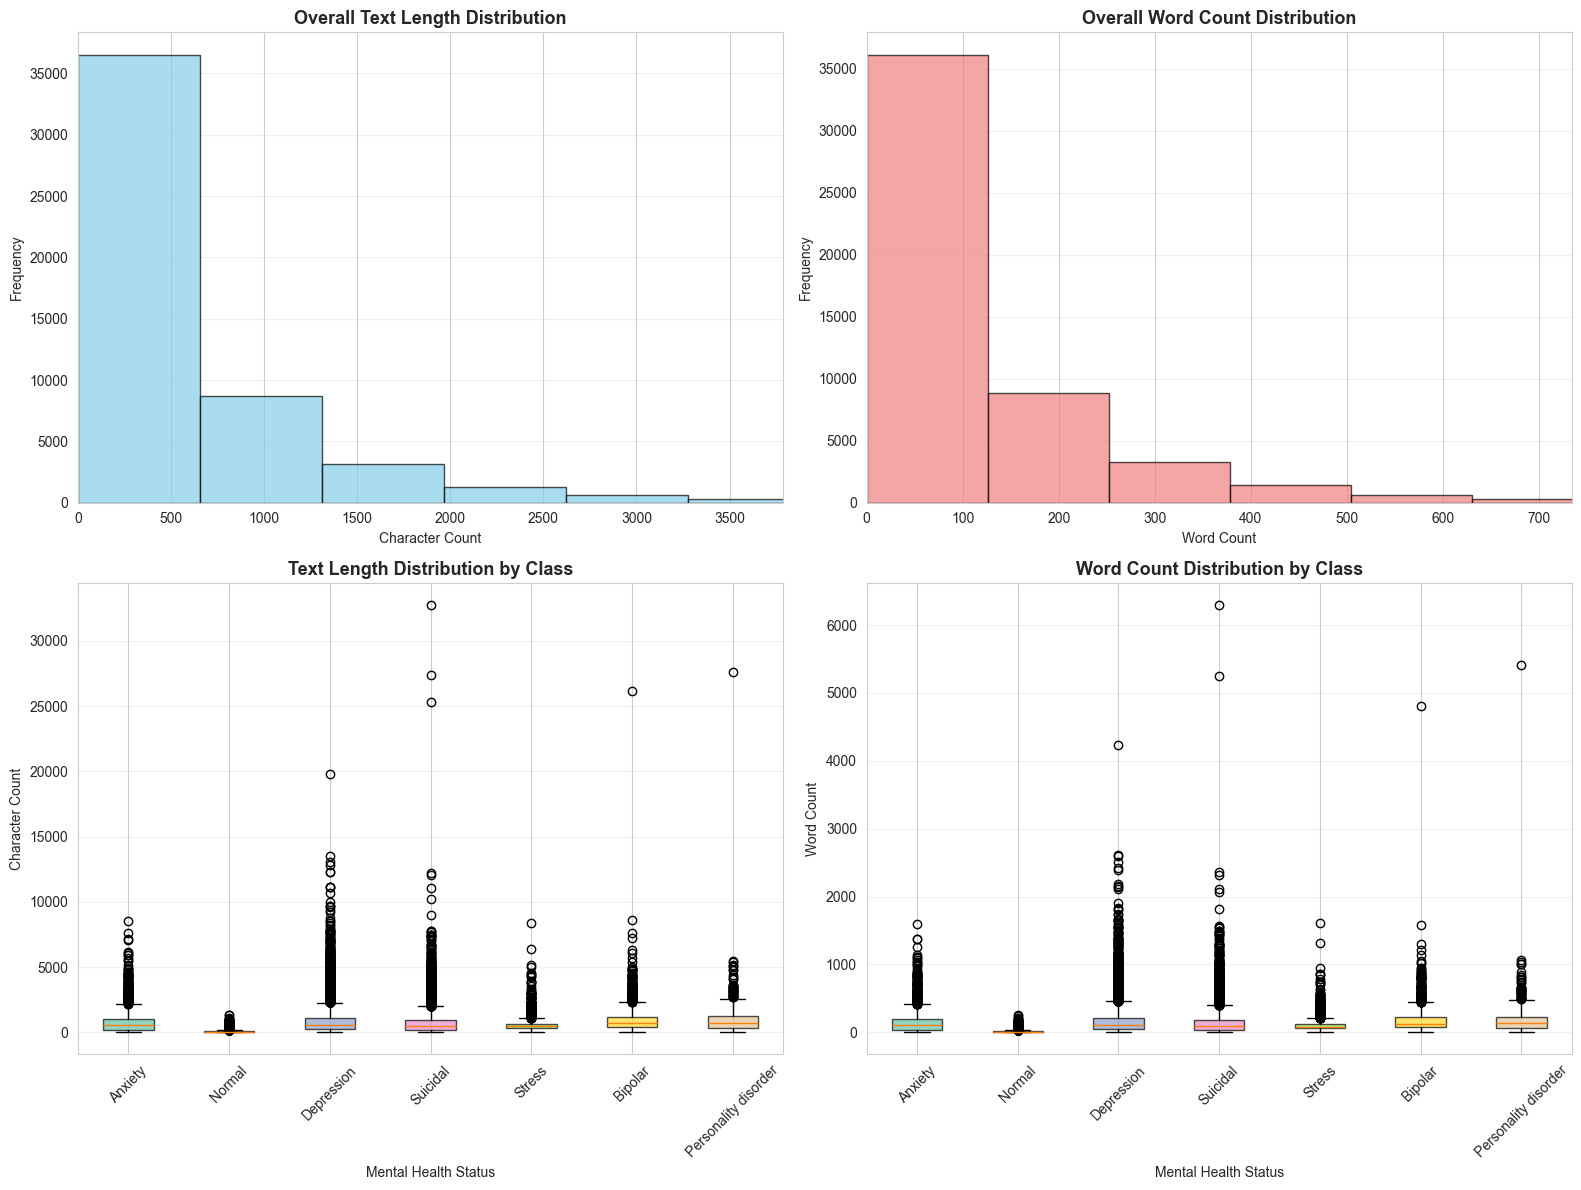


Statistical Summary by Class:

Anxiety:
  Avg Text Length: 761.0 chars
  Avg Word Count: 143.1 words
  Median Text Length: 543.5 chars
  Sample Count: 3624

Normal:
  Avg Text Length: 91.2 chars
  Avg Word Count: 17.4 words
  Median Text Length: 51.0 chars
  Sample Count: 16041

Depression:
  Avg Text Length: 844.8 chars
  Avg Word Count: 168.2 words
  Median Text Length: 562.0 chars
  Sample Count: 15094

Suicidal:
  Avg Text Length: 735.3 chars
  Avg Word Count: 146.5 words
  Median Text Length: 453.0 chars
  Sample Count: 10645

Stress:
  Avg Text Length: 593.7 chars
  Avg Word Count: 111.6 words
  Median Text Length: 451.0 chars
  Sample Count: 2297

Bipolar:
  Avg Text Length: 957.7 chars
  Avg Word Count: 178.2 words
  Median Text Length: 702.0 chars
  Sample Count: 2502

Personality disorder:
  Avg Text Length: 948.4 chars
  Avg Word Count: 177.7 words
  Median Text Length: 720.0 chars
  Sample Count: 896


In [100]:
# Visualize text length distribution with better visualization for 7 classes
if text_column:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Overall text length distribution
    axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Overall Text Length Distribution', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Character Count')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(axis='y', alpha=0.3)
    # Limit x-axis to 95th percentile to focus on main data distribution
    axes[0, 0].set_xlim(0, df['text_length'].quantile(0.99))
    
    # 2. Overall word count distribution
    axes[0, 1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Overall Word Count Distribution', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Word Count')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(axis='y', alpha=0.3)
    # Limit x-axis to 95th percentile to focus on main data distribution
    axes[0, 1].set_xlim(0, df['word_count'].quantile(0.99))
    
    # 3. Box plot: Text length by class (much better for comparing 7 categories)
    if label_column:
        # Prepare data for box plot
        box_data_length = [df[df[label_col] == label]['text_length'].values for label in df[label_col].unique()]
        bp1 = axes[1, 0].boxplot(box_data_length, labels=df[label_col].unique(), patch_artist=True)
        
        # Color the boxes
        colors = sns.color_palette('Set2', len(df[label_col].unique()))
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[1, 0].set_title('Text Length Distribution by Class', fontsize=13, fontweight='bold')
        axes[1, 0].set_xlabel('Mental Health Status')
        axes[1, 0].set_ylabel('Character Count')
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(axis='y', alpha=0.3)
        
        # 4. Box plot: Word count by class
        box_data_words = [df[df[label_col] == label]['word_count'].values for label in df[label_col].unique()]
        bp2 = axes[1, 1].boxplot(box_data_words, labels=df[label_col].unique(), patch_artist=True)
        
        # Color the boxes
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[1, 1].set_title('Word Count Distribution by Class', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Mental Health Status')
        axes[1, 1].set_ylabel('Word Count')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistical summary by class
    if label_column:
        print("\nStatistical Summary by Class:")
        print("=" * 80)
        for label in df[label_col].unique():
            subset = df[df[label_col] == label]
            print(f"\n{label}:")
            print(f"  Avg Text Length: {subset['text_length'].mean():.1f} chars")
            print(f"  Avg Word Count: {subset['word_count'].mean():.1f} words")
            print(f"  Median Text Length: {subset['text_length'].median():.1f} chars")
            print(f"  Sample Count: {len(subset)}")

## 2. Text Preprocessing Pipeline

### 2.1 Import Required Libraries

In [101]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data (with visible feedback)
print("Downloading NLTK data packages...")
print("This only needs to be done once.\n")

# Download each package and show status
# Note: 'punkt_tab' is required for newer NLTK versions (3.8+)
packages = ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']
for package in packages:
    print(f"Downloading '{package}'...", end=' ')
    try:
        result = nltk.download(package, quiet=True)
        print("✓")
    except Exception as e:
        print(f"⚠ {e}")

print("\n✓ All libraries imported successfully!")
print("✓ NLTK data packages ready!")

This only needs to be done once.


✓ All libraries imported successfully!
✓ NLTK data packages ready!


### 2.2 Text Cleaning Functions
Convert to lowercase, remove URLs, emails, mentions, special characters, and extra whitespaces.

In [102]:
def clean_text(text):
    """
    Clean text by:
    - Converting to lowercase
    - Removing URLs
    - Removing emails
    - Removing mentions (@user)
    - Removing special characters and numbers
    - Removing extra whitespaces
    """
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keep the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove special characters and numbers (keep basic punctuation for now)
    text = re.sub(r'[^a-zA-Z\s.,!?\'\-]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test the function
test_text = "Check this out! https://example.com @user123 Email: test@email.com #depression feeling really down 😔"
print("Original:", test_text)
print("Cleaned:", clean_text(test_text))

Original: Check this out! https://example.com @user123 Email: test@email.com #depression feeling really down 😔
Cleaned: check this out! email depression feeling really down


### 2.3 Handle Negations
Preserve negations as they're critical for sentiment analysis (e.g., "not happy" ≠ "happy").

In [103]:
def handle_negations(text):
    """
    Handle negations by attaching 'not_' prefix to words following negation terms.
    This preserves the negative sentiment (e.g., 'not happy' becomes 'not_happy')
    """
    negations = ["not", "no", "never", "neither", "nobody", "nothing", 
                 "nowhere", "hardly", "barely", "scarcely", "cant", "couldnt",
                 "shouldnt", "wont", "wouldnt", "dont", "doesnt", "didnt",
                 "isnt", "arent", "aint"]
    
    words = text.split()
    negated_text = []
    negate = False
    
    for i, word in enumerate(words):
        if word in negations:
            negate = True
            negated_text.append(word)
        elif negate:
            negated_text.append(f"not_{word}")
            # Stop negation after a punctuation or after 3 words
            if word[-1] in '.!?,;:' or i > 2:
                negate = False
        else:
            negated_text.append(word)
    
    return ' '.join(negated_text)

# Test the function
test_text = "I am not happy at all. I don't feel good."
print("Original:", test_text)
print("With negations:", handle_negations(test_text))

Original: I am not happy at all. I don't feel good.
With negations: I am not not_happy at all. I don't feel good.


### 2.4 Text Normalization
Remove stopwords (carefully - some may indicate depression) and apply lemmatization.

In [104]:
# Initialize lemmatizer (converts words to base form: "running" -> "run")
lemmatizer = WordNetLemmatizer()

# Get standard English stopwords from NLTK
stop_words = set(stopwords.words('english'))

print(f"NLTK stopwords count: {len(stop_words)}")

# IMPORTANT: For mental health detection, some stopwords are actually meaningful!
# Example: "I am NOT sad" vs "I am sad" - the word "not" is crucial!
# Example: "feeling down" - the word "down" indicates depression

# Define words to KEEP (do NOT remove) - they're important for mental health analysis
keep_words = {
    # Negation words (critical for sentiment!)
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere',
    'hardly', 'barely', 'scarcely', 
    "don't", 'don', "doesn't", 'doesn', "didn't", 'didn',
    "can't", "couldn't", 'couldn',
    "shouldn't", 'shouldn', "won't", 'won', "wouldn't", 'wouldn',
    "isn't", 'isn', "aren't", 'aren',
    "wasn't", 'wasn', "weren't", 'weren',
    "haven't", 'haven', "hasn't", 'hasn', "hadn't", 'hadn',
    "mightn't", 'mightn', "mustn't", 'mustn', "needn't", 'needn', "shan't", 'shan',
    'ain',
    # Mental health indicator words
    'down', 'alone', 'sad', 'depressed', 'hopeless', 'anxious', 'worried'
}

# Remove the important words from stopwords list
# So they WON'T be deleted during preprocessing
stop_words = stop_words - keep_words  # Set subtraction

print(f"Important words to keep: {len(keep_words)}")
print(f"Final stopwords to remove: {len(stop_words)}")
print(f"\n✓ Removed from stopwords (will be kept in text): {sorted(keep_words & {'not', 'no', 'nor', 'down', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'hardly', 'barely', 'scarcely', 'ain'})}")



NLTK stopwords count: 198
Important words to keep: 56
Final stopwords to remove: 157

✓ Removed from stopwords (will be kept in text): ['ain', 'barely', 'down', 'hardly', 'neither', 'never', 'no', 'nobody', 'nor', 'not', 'nothing', 'nowhere', 'scarcely']


In [105]:
def normalize_text(text):
    """
    Normalize text by:
    - Tokenizing (splits text into words)
    - Removing punctuation tokens
    - Removing stopwords (except important ones we defined earlier)
    - Lemmatizing (converting words to base form: "running" -> "run")
    """
    # Tokenize (splits into words and punctuation separately)
    tokens = word_tokenize(text)
    
    # Remove stopwords, punctuation, and lemmatize
    normalized_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word.lower() not in stop_words  # Not a stopword
        and len(word) > 2                   # At least 3 characters
        and word.isalpha()                  # Only alphabetic (removes punctuation!)
    ]
    
    return ' '.join(normalized_tokens)

# Test the function with punctuation to verify it works correctly
test_text = "i am feeling very sad and lonely these days!!!"
print("Original:", test_text)
print("Normalized:", normalize_text(test_text))
print("\nNotice: Punctuation '!!!' is removed, 'am' is removed (stopword), but 'sad' and 'lonely' are kept!")

Original: i am feeling very sad and lonely these days!!!
Normalized: feeling sad lonely day

Notice: Punctuation '!!!' is removed, 'am' is removed (stopword), but 'sad' and 'lonely' are kept!


### 2.5 Emoji Handling
Convert emojis to text descriptions or remove them.

In [106]:
def handle_emojis(text):
    """
    Remove or convert common emojis.
    For more sophisticated emoji handling, consider using the 'emoji' library.
    """
    # Simple emoji removal pattern
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    
    return emoji_pattern.sub(r'', text)

# Test the function
test_text = "I'm so sad 😢 and depressed 😔"
print("Original:", test_text)
print("Without emojis:", handle_emojis(test_text))

Original: I'm so sad 😢 and depressed 😔
Without emojis: I'm so sad  and depressed 


### 2.6 Noise Removal
Remove very short texts (< 3 words) that don't provide meaningful information.

In [107]:
def remove_noise(text, min_words=3):
    """
    Remove noise by:
    - Filtering out texts with less than min_words
    - Removing texts that are too short to be meaningful
    """
    words = text.split()
    if len(words) < min_words:
        return None
    return text

# Test the function
test_texts = ["ok", "I am sad", "feeling really depressed and anxious"]
for text in test_texts:
    result = remove_noise(text)
    print(f"'{text}' -> {result}")

'ok' -> None
'I am sad' -> I am sad
'feeling really depressed and anxious' -> feeling really depressed and anxious


### 2.7 Complete Preprocessing Pipeline
Combine all preprocessing steps into a single function.

In [108]:
def preprocess_text(text):
    """
    Complete preprocessing pipeline that applies all steps:
    1. Clean text
    2. Handle emojis
    3. Handle negations
    4. Normalize text
    5. Remove noise
    """
    # Step 1: Clean text
    text = clean_text(text)
    
    # Step 2: Handle emojis
    text = handle_emojis(text)
    
    # Step 3: Handle negations
    text = handle_negations(text)
    
    # Step 4: Normalize text
    text = normalize_text(text)
    
    # Step 5: Remove noise
    text = remove_noise(text)
    
    return text

# Test the complete pipeline
test_text = "I'm NOT happy at all! 😢 Check this: https://example.com @user #depression"
print("Original:", test_text)
print("Preprocessed:", preprocess_text(test_text))

Original: I'm NOT happy at all! 😢 Check this: https://example.com @user #depression
Preprocessed: not check depression


### 2.8 Apply Preprocessing to Dataset
Apply the preprocessing pipeline to all text samples.

In [109]:
# Apply preprocessing to the text column
if text_column:
    print(f"Preprocessing '{text_col}' column...")
    print("This may take a few minutes...\n")
    
    # Create a copy for comparison
    df['original_text'] = df[text_col].copy()
    
    # Apply preprocessing
    from tqdm import tqdm
    tqdm.pandas(desc="Preprocessing")
    
    df['cleaned_text'] = df[text_col].progress_apply(preprocess_text)
    
    # Remove rows with None values (texts that were too short)
    initial_count = len(df)
    df = df[df['cleaned_text'].notna()]
    removed_count = initial_count - len(df)
    
    print(f"\n✓ Preprocessing complete!")
    print(f"Removed {removed_count} samples that were too short.")
    print(f"Remaining samples: {len(df)}")
else:
    print("Please specify the text column name manually.")

Preprocessing 'statement' column...
This may take a few minutes...



Preprocessing: 100%|██████████| 51099/51099 [01:10<00:00, 724.95it/s] 


✓ Preprocessing complete!
Removed 3860 samples that were too short.
Remaining samples: 47239


### 2.9 Compare Original vs Preprocessed Text
View examples of the preprocessing results.

In [110]:
# Display comparison of original and preprocessed text
if text_column and 'cleaned_text' in df.columns:
    print("Sample Comparisons (Original vs Preprocessed):")
    print("=" * 80)
    
    # Show random samples
    for i, idx in enumerate(df.sample(5).index):
        print(f"\nExample {i+1}:")
        print(f"Original:     {df.loc[idx, 'original_text'][:150]}")
        print(f"Preprocessed: {df.loc[idx, 'cleaned_text'][:150]}")
        print("-" * 80)

Sample Comparisons (Original vs Preprocessed):

Example 1:
Original:     I am sobbing while I write this post. I do not think I am in extremely imminent danger so I am probably not a super high priority, but if even one per
Preprocessed: sobbing write post not extremely imminent danger probably not super high priority even one person could help would mean world never would post subredd
--------------------------------------------------------------------------------

Example 2:
Original:     DON'T TAKE THE POCKETS ARE OUT OF LEBARAN... Gaesss... It's already a finger count towards Lebaran... Yesterday, I would have done this and that. How 
Preprocessed: take pocket lebaran gaesss already finger count towards lebaran yesterday would done eid still left
--------------------------------------------------------------------------------

Example 3:
Original:     Ill be depressed for the rest of my life. I know this because everything out there is shit and its not going to change and my brain 

### 2.10 Save Preprocessed Data
Save the preprocessed dataset for future use.

In [111]:
# Save preprocessed data
if 'cleaned_text' in df.columns:
    # Save to CSV
    output_file = 'preprocessed_data.csv'
    df.to_csv(output_file, index=False)
    print(f"✓ Preprocessed data saved to '{output_file}'")
    print(f"\nFinal dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

✓ Preprocessed data saved to 'preprocessed_data.csv'

Final dataset shape: (47239, 6)
Columns: ['statement', 'status', 'text_length', 'word_count', 'original_text', 'cleaned_text']


## Class Distribution After Preprocessing 

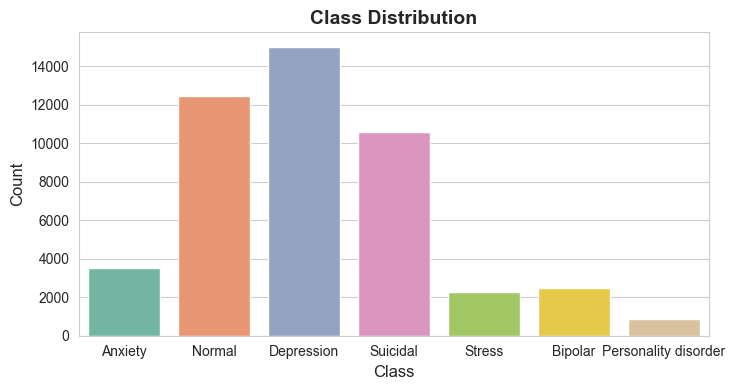

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(14, 4))

if label_column:
    # Count plot
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=label_column[0], palette='Set2')
    plt.title('Class Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)

    
    plt.tight_layout()
    plt.show()

## Summary

### Data Exploration Completed:
- ✓ Dataset structure inspection (3 columns: ID, Statement, Status)
- ✓ Missing values analysis
- ✓ Duplicate removal
- ✓ Multi-class distribution analysis (7 mental health categories)
- ✓ Text length distribution

### Text Preprocessing Completed:
- ✓ Text cleaning (lowercase, URLs, emails, mentions)
- ✓ Special character removal
- ✓ Negation handling
- ✓ Stopword removal (with exceptions)
- ✓ Lemmatization
- ✓ Emoji handling
- ✓ Noise removal

### Next Steps:
1. Feature extraction (TF-IDF, sentiment scores, n-grams)
2. Handle class imbalance (class weights, SMOTE, or oversampling)
3. Multi-class model training (Logistic Regression, SVM, Random Forest, XGBoost)
4. Model evaluation (Accuracy, Precision, Recall, F1-Score per class, Confusion Matrix)
5. Model interpretation and feature importance